<a href="https://colab.research.google.com/github/ssykes-eth/ETH_273-0003-00L/blob/weekend_3/interpretability_unsolved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpretability in Deep Learning: A Hands-On Tour

---

## What is Interpretability?

Imagine you hire a brilliant consultant who gives you great advice — but can never explain *why*. You'd probably feel uneasy trusting them with high-stakes decisions. Modern machine learning models are exactly like that consultant: often accurate, rarely explainable.

**Interpretability** is the field that asks: *What did the model actually learn? Why did it make this prediction? Is it reasoning the right way, or just exploiting a lucky pattern?*

### Why Does It Matter?

- **Safety**: A self-driving car that works for the wrong reasons will fail in unexpected ways.
- **Fairness**: A loan model might achieve high accuracy by learning a protected attribute (race, gender) as a proxy.
- **Science**: In medicine or biology, we don't just want predictions — we want to *understand* the system.
- **Debugging**: When a model fails, interpretability tools help you figure out *why*.

### The Clever Hans Warning

Clever Hans was a horse in early 20th-century Germany, famous for apparently solving arithmetic problems. Investigators eventually discovered he wasn't calculating , he was reading subtle postural cues from his trainer. He had the right *outputs* for the wrong *reasons*.

Deep learning models do this constantly. **High accuracy ≠ correct reasoning.**

---

## What You'll Learn in This Notebook

| Section | Technique | What It Answers |
|---|---|---|
| 1 | Shortcut Learning | How models cheat |
| 2 | LIME | Why did THIS prediction happen? |
| 3 | SHAP | Which features matter globally? |
| 4 | Grad-CAM | Where did the CNN look? |

**Prerequisites**: Python, basic ML (train/test, sklearn), familiarity with neural networks at the conceptual level.

Let's dig in.

In [9]:
#@title Install {display-mode: "form"}
# If you're on Colab or a fresh environment, uncomment the line below:
!pip install shap lime torch torchvision matplotlib seaborn scikit-learn numpy pandas captum --quiet

In [10]:
#@title Import libraries {display-mode: "form"}
# ── Core scientific stack ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.colors import Normalize

# ── Sklearn ────────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE
from sklearn.neural_network import MLPClassifier

# ── LIME & SHAP ────────────────────────────────────────────────────────────
import lime
import lime.lime_tabular
import shap

# ── PyTorch ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ── Reproducibility ────────────────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
CMAP = 'RdBu_r'

print('All imports successful!')
print(f'PyTorch version: {torch.__version__}')

All imports successful!
PyTorch version: 2.10.0+cpu


---
# Section 1 — Shortcut Learning: The Clever Hans Problem

## The Core Idea

Models learn to minimize loss on *training data*. If there's a feature in the training data that perfectly predicts the label but is meaningless in the real world, the model will happily use it. This is called **shortcut learning** (also called **Clever Hans behavior** or **spurious correlations**).

**Real-world examples:**
- A pneumonia classifier that learned to predict *lower* risk for asthma patients because asthma patients always went to the ICU and got aggressive treatment (so they had better outcomes in the training data).
- A cow vs. camel classifier that actually learned to detect *grass vs. sand* backgrounds.
- COVID X-ray classifiers that learned hospital-specific metadata (scanner type, patient position) instead of actual pathology.

## What We'll Do

We'll create a synthetic dataset with:
- 2 real signal features (genuinely predictive)
- 3 noise features (random, not predictive)
- 1 spurious feature (perfectly correlated with `y` in training, but random at test time)

Then we'll train a logistic regression and watch it get fooled.

> **💡 Key Insight**: A model that achieves 100% training accuracy isn't necessarily learning the right thing. Interpretability tools help us audit *what* was learned.


### Dataset Construction

We build a synthetic binary-classification dataset with **6 features**:

- **Real signal** (`signal_1`, `signal_2`): drawn from class-shifted Gaussian distributions — genuinely predictive of the label.
- **Noise** (`noise_1`, `noise_2`, `noise_3`): completely random, independent of the label.
- **Spurious** (`spurious`): nearly perfectly correlated with the label *during training* (99% match), but replaced with pure noise *at test time* to expose the shortcut.

In [11]:
np.random.seed(42)
N = 1000

y = np.random.randint(0, 2, size=N)           # binary labels
X_signal = np.column_stack([
    np.random.randn(N) + y * 1.5,             # feature 0: shifted by label
    np.random.randn(N) + y * 1.0,             # feature 1: smaller shift
])

X_noise = np.random.randn(N, 3)               # features 2,3,4

spurious_train = y.copy().astype(float) + np.random.randn(N) * 0.01
spurious_test  = np.random.randn(N)           # pure noise at test time

X_all_train = np.column_stack([X_signal, X_noise, spurious_train])
X_all_test  = np.column_stack([X_signal, X_noise, spurious_test])

idx = np.arange(N)
np.random.shuffle(idx)
train_idx, test_idx = idx[:700], idx[700:]

X_train = X_all_train[train_idx]
X_test  = X_all_test[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

feature_names = ['signal_1', 'signal_2', 'noise_1', 'noise_2', 'noise_3', 'spurious']
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'Features: {feature_names}')

Train size: 700, Test size: 300
Features: ['signal_1', 'signal_2', 'noise_1', 'noise_2', 'noise_3', 'spurious']


### Dataset Overview

The synthetic dataset has **6 features** split into three groups:

| Feature | Type | Description |
|---|---|---|
| `signal_1`, `signal_2` | ✅ Real signal | Drawn from class-shifted distributions — genuinely predictive |
| `noise_1`, `noise_2`, `noise_3` | ❌ Pure noise | Completely random, independent of the label |
| `spurious` | ⚠️ Shortcut | 99% correlated with the label *in training*, but pure noise *at test time* |

The plots below visualize the training data. Notice how the spurious feature has the highest feature–label correlation in training — a model that exploits it will appear to perform well but will fail at deployment.

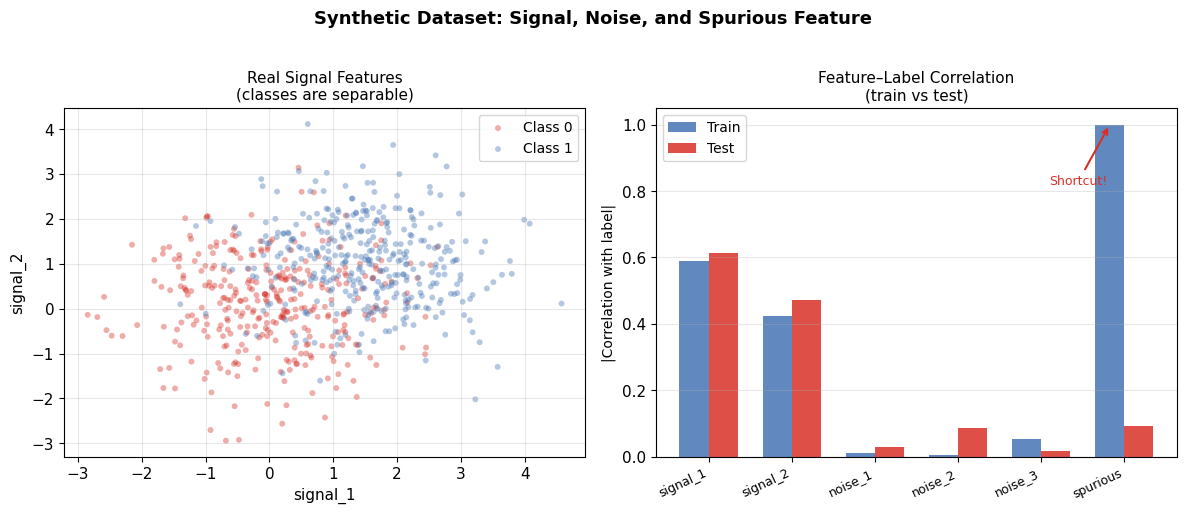

In [12]:
#@title Dataset Visualization {display-mode: "form"}
# ── Three-panel overview of the synthetic dataset ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Synthetic Dataset: Signal, Noise, and Spurious Feature',
             fontsize=13, fontweight='bold', y=1.02)

colors = {0: '#d73027', 1: '#4575b4'}
labels_str = {0: 'Class 0', 1: 'Class 1'}

# ── Panel 1: Scatter of the two real signal features ──────────────────────
ax = axes[0]
for cls in [0, 1]:
    mask = y_train == cls
    ax.scatter(X_train[mask, 0], X_train[mask, 1],
               c=colors[cls], label=labels_str[cls],
               alpha=0.4, s=18, edgecolors='none')
ax.set_xlabel('signal_1', fontsize=11)
ax.set_ylabel('signal_2', fontsize=11)
ax.set_title('Real Signal Features\n(classes are separable)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Panel 2: Absolute feature–label correlation, train vs test ────────────
ax = axes[1]
corr_train = [abs(np.corrcoef(X_train[:, i], y_train)[0, 1]) for i in range(X_train.shape[1])]
corr_test  = [abs(np.corrcoef(X_test[:, i],  y_test )[0, 1]) for i in range(X_test.shape[1])]
x_pos = np.arange(len(feature_names))
width = 0.35
bars_tr = ax.bar(x_pos - width/2, corr_train, width, label='Train',
                  color='#4575b4', alpha=0.85)
bars_te = ax.bar(x_pos + width/2, corr_test,  width, label='Test',
                  color='#d73027', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('|Correlation with label|', fontsize=10)
ax.set_title('Feature–Label Correlation\n(train vs test)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
# Annotate the spurious bar to highlight the trap
ax.annotate('Shortcut!', xy=(5 - width/2, corr_train[5]),
            xytext=(4.1, 0.82), fontsize=9, color='#d73027',
            arrowprops=dict(arrowstyle='->', color='#d73027', lw=1.5))

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=120, bbox_inches='tight')
plt.show()


### Training a Logistic Regression

We train a logistic regression classifier on the full 6-feature dataset and compare train vs. test accuracy. We then inspect the coefficient magnitudes to see which features the model weighted most heavily.

In [13]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc  = accuracy_score(y_test,  clf.predict(X_test))

print(f'Train accuracy: {train_acc:.3f}   <-- suspiciously high!')
print(f'Test  accuracy: {test_acc:.3f}    <-- dropped because spurious feature is now random')
print()

coefs = pd.Series(np.abs(clf.coef_[0]), index=feature_names).sort_values(ascending=False)
print('Coefficient magnitudes (absolute value):')
print(coefs.to_string())
print()
print('>>> The SPURIOUS feature has the largest coefficient!')
print('>>> The model learned the shortcut instead of the real signal.')

Train accuracy: 1.000   <-- suspiciously high!
Test  accuracy: 0.507    <-- dropped because spurious feature is now random

Coefficient magnitudes (absolute value):
spurious    6.968088
signal_1    0.703761
signal_2    0.492522
noise_3     0.026005
noise_2     0.011479
noise_1     0.001194

>>> The SPURIOUS feature has the largest coefficient!
>>> The model learned the shortcut instead of the real signal.


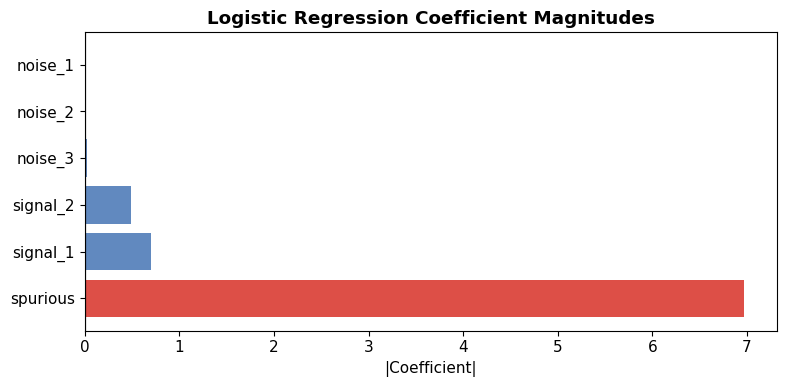

In [14]:
#@title Logistic regression coefficient Magnitudes {display-mode: "form"}
# ── Coefficient bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d73027' if n == 'spurious' else '#4575b4' for n in coefs.index]
ax.barh(coefs.index, coefs.values, color=colors, alpha=0.85)
ax.set_xlabel('|Coefficient|')
ax.set_title('Logistic Regression Coefficient Magnitudes', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Permutation Importance

Permutation importance measures how much test accuracy **drops** when you randomly shuffle a feature (breaking its relationship with the label). On test data, the spurious feature is already random — so shuffling it should matter very little. We compute this on both train and test to expose the discrepancy.

In [15]:
perm_train = permutation_importance(clf, X_train, y_train, n_repeats=30, random_state=42)
perm_test  = permutation_importance(clf, X_test,  y_test,  n_repeats=30, random_state=42)

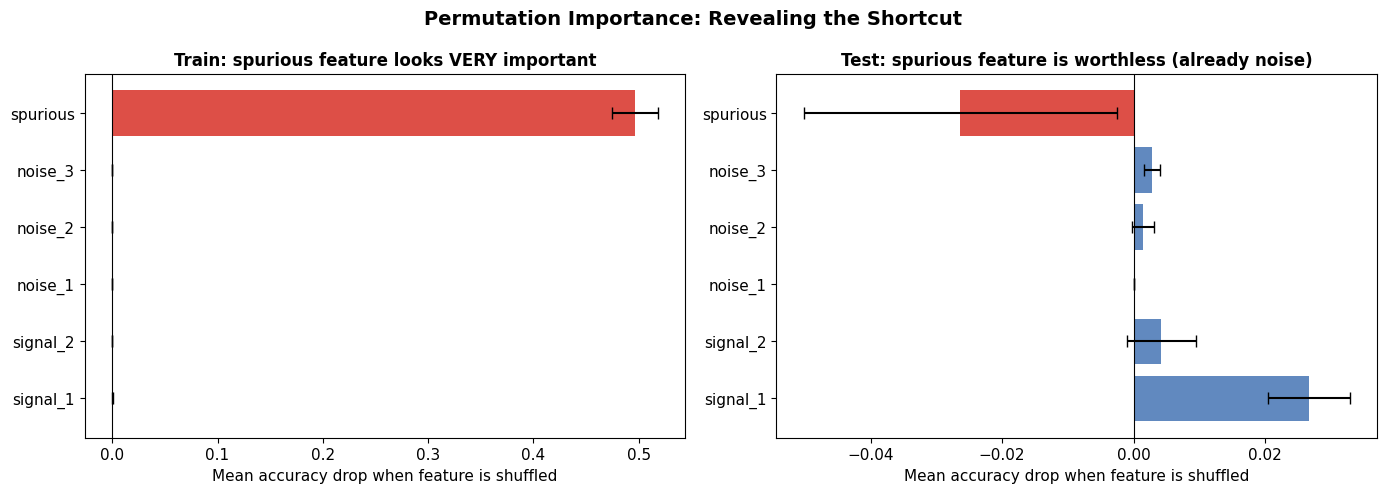

In [16]:
#@title Visualization Permutance importance {display-mode: "form"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, perm, split in zip(axes, [perm_train, perm_test], ['Train', 'Test']):
    means = perm.importances_mean
    stds  = perm.importances_std
    colors = ['#d73027' if n == 'spurious' else '#4575b4' for n in feature_names]
    bars = ax.barh(feature_names, means, xerr=stds, color=colors, alpha=0.85, capsize=4)
    ax.set_title(f'Permutation Importance ({split} set)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean accuracy drop when feature is shuffled')
    ax.axvline(0, color='black', linewidth=0.8)

axes[0].set_title('Train: spurious feature looks VERY important', fontsize=12, fontweight='bold')
axes[1].set_title('Test: spurious feature is worthless (already noise)', fontsize=12, fontweight='bold')

fig.suptitle('Permutation Importance: Revealing the Shortcut', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

On training data, the spurious feature looks crucial.
On test data, it contributes nothing - exposing the shortcut.

> **⚠️ Watch Out**: Permutation importance on *training* data can be misleading for overfitted models. Always verify on a held-out test set. The gap between train and test importance is itself a signal of a shortcut.

## 🏋️ Exercise

1. **Remove the spurious feature** entirely and retrain. What happens to train and test accuracy? Do the coefficients look healthier now?

2. **Weaken the shortcut**: Instead of 99% correlation, make the spurious feature only 80% correlated with `y` in training (hint: increase the noise: `spurious_train = y + np.random.randn(N) * X` - what value of X gives ~80%?). How does this affect the model's behavior?

3. **Bonus**: What if you had *no* signal features at all ,just noise and one spurious feature? What would the test accuracy be, and why?


In [18]:
# 1) Remove the spurious feature entirely and retrain

# 🎯🎯🎯 TODO: Drop the last column (spurious) from X_train and X_test 🎯🎯🎯
X_train_no_spurious = X_train[:, :-1]
X_test_no_spurious  = X_test[:, :-1]

# 🎯🎯🎯 TODO: Fit a new LogisticRegression(max_iter=1000, random_state=42) on X_train_no_spurious 🎯🎯🎯
mod_no_spur = LogisticRegression(max_iter=1000, random_state=42)
mod_no_spur.fit(X_train_no_spurious, y_train)

# 🎯🎯🎯 TODO: Compute train and test accuracy using accuracy_score 🎯🎯🎯
train_acc_ns = accuracy_score(y_train, mod_no_spur.predict(X_train_no_spurious))
test_acc_ns  = accuracy_score(y_test,  mod_no_spur.predict(X_test_no_spurious))

print(f'[with spurious]    Train: {train_acc:.3f}  Test: {test_acc:.3f}')
print(f'[without spurious]  Train: {train_acc_ns:.3f}  Test: {test_acc_ns:.3f}')

feature_names_ns = ['signal_1', 'signal_2', 'noise_1', 'noise_2', 'noise_3']
coefs_ns = pd.Series(np.abs(mod_no_spur.coef_[0]), index=feature_names_ns).sort_values(ascending=False)
print('\nCoefficient (without spurious):')
print(coefs_ns.to_string())

[with spurious]    Train: 1.000  Test: 0.507
[without spurious]  Train: 0.830  Test: 0.837

Coefficient (without spurious):
signal_1    1.412921
signal_2    1.028329
noise_3     0.078422
noise_2     0.038799
noise_1     0.020844


In [19]:
# 2) Weaken the spurious feature to ~80% correlation
np.random.seed(42)

# 🎯🎯🎯 TODO: Create spurious_train_weak = y + np.random.randn(N) * 0.75 🎯🎯🎯
spurious_train_weak = y + np.random.randn(N) * 0.75

X_all_train_weak = np.column_stack([X_signal, X_noise, spurious_train_weak])
# 🎯🎯🎯 TODO: Select rows using train_idx to get X_train_weak 🎯🎯🎯
X_train_weak = X_all_train_weak[train_idx]

# 🎯🎯🎯 TODO: Fit clf_weak = LogisticRegression(max_iter=1000, random_state=42) on X_train_weak
#             Compute train_acc_w (on X_train_weak) and test_acc_w (on X_test!) 🎯🎯🎯
clf_weak = LogisticRegression(max_iter=1000, random_state=42)
clf_weak.fit(X_train_weak, y_train)
train_acc_w = accuracy_score(y_train, clf_weak.predict(X_train_weak))
test_acc_w  = accuracy_score(y_test,  clf_weak.predict(X_test))

print(f'[99% corr]  Train: {train_acc:.3f}  Test: {test_acc:.3f}')
print(f'[80% corr]  Train: {train_acc_w:.3f}  Test: {test_acc_w:.3f}')
print()
coefs_w = pd.Series(np.abs(clf_weak.coef_[0]), index=feature_names).sort_values(ascending=False)
print('Coefficient (80% correlation):')
print(coefs_w.to_string())

[99% corr]  Train: 1.000  Test: 0.507
[80% corr]  Train: 0.874  Test: 0.730

Coefficient (80% correlation):
spurious    1.601969
signal_1    1.356990
signal_2    0.919876
noise_3     0.084773
noise_1     0.016921
noise_2     0.013899


In [20]:
# 3) Bonus: no signal features at all — only noise + spurious

# 🎯🎯🎯 TODO: Build X_nosignal_train using np.column_stack of X_noise[train_idx] and spurious_train[train_idx] 🎯🎯🎯
X_nosignal_train = np.column_stack([X_noise[train_idx], spurious_train[train_idx]])
# 🎯🎯🎯 TODO: Build X_nosignal_test using X_noise[test_idx] and spurious_test[test_idx] 🎯🎯🎯
X_nosignal_test  = np.column_stack([X_noise[test_idx], spurious_test[test_idx]])

# 🎯🎯🎯 TODO: Fit clf_nosig = LogisticRegression(...) and compute train_acc_bg, test_acc_bg 🎯🎯🎯
clf_nosig = LogisticRegression(max_iter=1000, random_state=42)
clf_nosig.fit(X_nosignal_train, y_train)
train_acc_bg = accuracy_score(y_train, clf_nosig.predict(X_nosignal_train))
test_acc_bg  = accuracy_score(y_test,  clf_nosig.predict(X_nosignal_test))

print(f'Train acc: {train_acc_bg:.3f}')
print(f'Test  acc: {test_acc_bg:.3f}')

Train acc: 1.000
Test  acc: 0.467


---
# Section 2 — LIME: Local Explanations

## The Big Idea

Global model interpretation is hard — complex models carve out decision boundaries in ways that are difficult to summarize globally. But **locally**, near any single prediction, even a complex model can often be approximated by something simple.

**LIME** (Local Interpretable Model-agnostic Explanations, Ribeiro et al. 2016) exploits this:

1. Take a single prediction you want to explain.
2. Create many slightly perturbed versions of that input.
3. Run them through the black-box model to get predictions.
4. Fit a **simple linear model** (interpretable) on this synthetic neighborhood, weighted by distance to the original point.
5. The linear model's coefficients are your explanation.

**Analogy**: You can't describe the entire topography of a mountain range, but you can say "right where you're standing, the ground slopes slightly north-east."

> **💡 Key Insight**: LIME explanations are *local* — they explain a single prediction, not the model's overall behavior. Two nearby points can have very different LIME explanations if the decision boundary is complex in that region.

> **⚠️ Watch Out**: LIME explanations are **approximate**. The quality of the explanation depends on how well a linear model can approximate the local behavior. For highly non-linear boundaries, LIME can be misleading.


### Load Dataset and Train a Black-Box Random Forest

We use the **Breast Cancer Wisconsin** dataset and train a Random Forest classifier. This serves as the black-box model we will explain with LIME.

In [21]:
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
feat_names_bc = bc.feature_names
class_names_bc = bc.target_names  # ['malignant', 'benign']

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

print(f'Dataset loaded: {X_bc.shape[0]} samples, {X_bc.shape[1]} features')
print(f'Classes: {class_names_bc}')

Dataset loaded: 569 samples, 30 features
Classes: ['malignant' 'benign']


### Quick Feature Dictionary

Below is a compact table of the breast cancer dataset features and what each feature represents.

In [22]:
#@title Visualization Features {display-mode: "form"}
#  Feature dictionary table: what each feature means
measurement_meanings = {
    'radius': 'Mean distance from center to perimeter points',
    'texture': 'Variation in gray-scale intensities',
    'perimeter': 'Tumor perimeter length',
    'area': 'Tumor area',
    'smoothness': 'Local variation in radius lengths',
    'compactness': 'perimeter^2 / area - 1.0',
    'concavity': 'Severity of concave portions of contour',
    'concave points': 'Number/severity of concave contour portions',
    'symmetry': 'Symmetry of the tumor shape',
    'fractal dimension': 'Coastline approximation complexity measure',
}

rows = []
for f in feat_names_bc:
    if f.startswith('mean '):
        measurement = f.replace('mean ', '', 1)
        statistic = 'Mean value across sampled cell nuclei'
    elif f.endswith(' error'):
        measurement = f.replace(' error', '')
        statistic = 'Standard error across sampled cell nuclei'
    elif f.startswith('worst '):
        measurement = f.replace('worst ', '', 1)
        statistic = 'Worst (largest) value across sampled cell nuclei'
    else:
        measurement = f
        statistic = 'Derived measurement'

    rows.append({
        'Feature': f,
        'What it measures': measurement_meanings.get(measurement, measurement),
        'Statistic type': statistic,
    })

feature_table = pd.DataFrame(rows)
print('Feature dictionary for the Breast Cancer dataset:')
display(feature_table)

Feature dictionary for the Breast Cancer dataset:


,Feature,What it measures,Statistic type
0,mean radius,Mean distance from center to perimeter points,Mean value across sampled cell nuclei
1,mean texture,Variation in gray-scale intensities,Mean value across sampled cell nuclei
2,mean perimeter,Tumor perimeter length,Mean value across sampled cell nuclei
3,mean area,Tumor area,Mean value across sampled cell nuclei
4,mean smoothness,Local variation in radius lengths,Mean value across sampled cell nuclei
5,mean compactness,perimeter^2 / area - 1.0,Mean value across sampled cell nuclei
6,mean concavity,Severity of concave portions of contour,Mean value across sampled cell nuclei
7,mean concave points,Number/severity of concave contour portions,Mean value across sampled cell nuclei
8,mean symmetry,Symmetry of the tumor shape,Mean value across sampled cell nuclei
9,mean fractal dimension,Coastline approximation complexity measure,Mean value across sampled cell nuclei


In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_bc_train, y_bc_train)

rf_test_acc = accuracy_score(y_bc_test, rf.predict(X_bc_test))
print(f'Random Forest test accuracy: {rf_test_acc:.4f}')

Random Forest test accuracy: 0.9561


### How LIME Works — Theory

LIME approximates the black-box model **locally** around a single input by solving an interpretable surrogate problem. For a given test sample $x$ (e.g. one patient's tumour measurements), LIME:

1. **Perturbs** the input by randomly masking or shifting feature values, generating a set of neighbours $\{z_1, \dots, z_n\}$.
2. **Queries** the black-box model $f$ (here, the Random Forest) on each neighbour to get predictions $f(z_i)$.
3. **Weights** each neighbour by how close it is to the original $x$ using an exponential kernel $\pi_x(z_i)$.
4. **Fits** a sparse linear model $g$ (the surrogate) by minimising:

$$g^* = \arg\min_{g} \sum_i \pi_x(z_i)\,\bigl(f(z_i) - g(z_i)\bigr)^2 + \Omega(g)$$

where $\Omega(g)$ penalises model complexity (number of non-zero coefficients). The resulting coefficients are the explanation.

---

**In the breast cancer context:**

| LIME concept | What it maps to here |
|---|---|
| Input $x$ | A single patient's 30 tumour measurements (radius, texture, …) |
| Black-box $f$ | The Random Forest (95%+ accuracy, but opaque) |
| Perturbations $z_i$ | Slightly modified copies of the patient's measurements |
| Surrogate $g^*$ | A linear model valid *near this patient* |
| Coefficient sign | **Positive** → pushes prediction towards the predicted class; **Negative** → pushes against it |


### Set Up the LIME Explainer

We initialize a `LimeTabularExplainer` on the training data and select three test samples to explain: one confidently correct benign, one confidently correct malignant, and one the model predicted incorrectly.

In [24]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_bc_train,
    feature_names=feat_names_bc,
    class_names=class_names_bc,
    mode='classification',
    random_state=42
)


preds = rf.predict(X_bc_test)
probs = rf.predict_proba(X_bc_test)

# Find interesting samples
correct_benign   = np.where((preds == 1) & (y_bc_test == 1) & (probs[:,1] > 0.95))[0]
correct_malig    = np.where((preds == 0) & (y_bc_test == 0) & (probs[:,0] > 0.90))[0]
wrong_preds      = np.where(preds != y_bc_test)[0]

sample_ids = [correct_benign[0], correct_malig[0], wrong_preds[0] if len(wrong_preds) > 0 else correct_benign[1]]
sample_labels = ['Correct: Benign', 'Correct: Malignant', 'Incorrect prediction' if len(wrong_preds) > 0 else 'Correct: Benign (2)']

print(f'Selected samples: indices {sample_ids}')
for i, sid in enumerate(sample_ids):
    true_cls  = class_names_bc[y_bc_test[sid]]
    pred_cls  = class_names_bc[preds[sid]]
    conf      = probs[sid].max()
    print(f'  Sample {sid}: True={true_cls}, Pred={pred_cls}, Confidence={conf:.3f}  [{sample_labels[i]}]')

Selected samples: indices [np.int64(1), np.int64(0), np.int64(3)]
  Sample 1: True=benign, Pred=benign, Confidence=1.000  [Correct: Benign]
  Sample 0: True=malignant, Pred=malignant, Confidence=1.000  [Correct: Malignant]
  Sample 3: True=benign, Pred=malignant, Confidence=0.720  [Incorrect prediction]


**Reading the bar charts below:** each bar is one feature's coefficient in the local linear model. A long blue bar means that feature's value strongly *supports* the predicted diagnosis, while red pushes against the predicted class - for *this particular patient* — it says nothing about other patients.

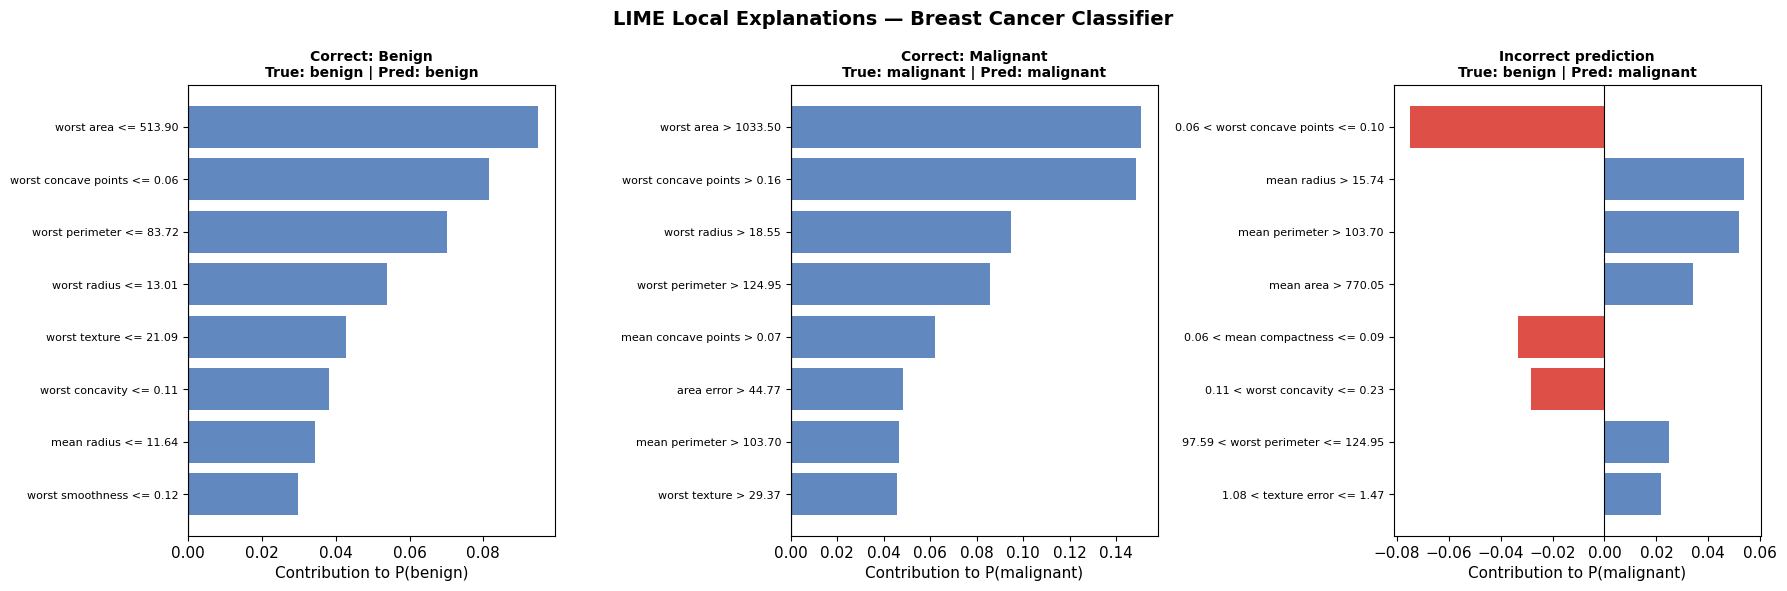

In [25]:
# ── Generate and plot LIME explanations ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax_idx, (sid, label) in enumerate(zip(sample_ids, sample_labels)):
    # Generate LIME explanation — pass labels=(0,1) so both classes are stored
    exp = explainer_lime.explain_instance(
        data_row=X_bc_test[sid],
        predict_fn=rf.predict_proba,
        num_features=8,
        num_samples=1000,
        labels=(0, 1)          # fix: explicitly compute both class explanations
    )

    # Extract feature contributions for the predicted class
    pred_class = int(preds[sid])   # fix: cast np.int64 → int so dict lookup works
    explanation_list = exp.as_list(label=pred_class)
    feat_labels = [e[0] for e in explanation_list]
    feat_values = [e[1] for e in explanation_list]

    # Sort by absolute value
    sorted_pairs = sorted(zip(feat_labels, feat_values), key=lambda x: abs(x[1]))
    feat_labels_s = [p[0] for p in sorted_pairs]
    feat_values_s = [p[1] for p in sorted_pairs]

    colors = ['#d73027' if v < 0 else '#4575b4' for v in feat_values_s]
    ax = axes[ax_idx]
    ax.barh(range(len(feat_labels_s)), feat_values_s, color=colors, alpha=0.85)
    ax.set_yticks(range(len(feat_labels_s)))
    ax.set_yticklabels(feat_labels_s, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    true_cls = class_names_bc[y_bc_test[sid]]
    pred_cls = class_names_bc[preds[sid]]
    ax.set_title(f'{label}\nTrue: {true_cls} | Pred: {pred_cls}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Contribution to P({pred_cls})')

fig.suptitle('LIME Local Explanations — Breast Cancer Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏋️ Exercise

1. **Wrong prediction investigation**: Find the sample the model predicted incorrectly. Look at its LIME explanation. Do the features highlighted suggest why the model was confused? Does the local explanation make sense given what you know about breast cancer features (radius, texture, smoothness...)?

2. **Same-class comparison**: Find two samples that are both correctly classified as *benign*. Generate LIME explanations for both. Are the explanations similar (same features highlighted, same direction)? What does this tell you about how locally consistent the model is?

3. **Stability check**: Run LIME on the same sample three times with different `num_samples` (100, 500, 5000). How stable are the explanations? Does the ranking of features change?


Misclassified: 5 samples -> indices: [ 3 25 35 53 65]

Sample 3: True=benign, Pred=malignant, Conf=0.720


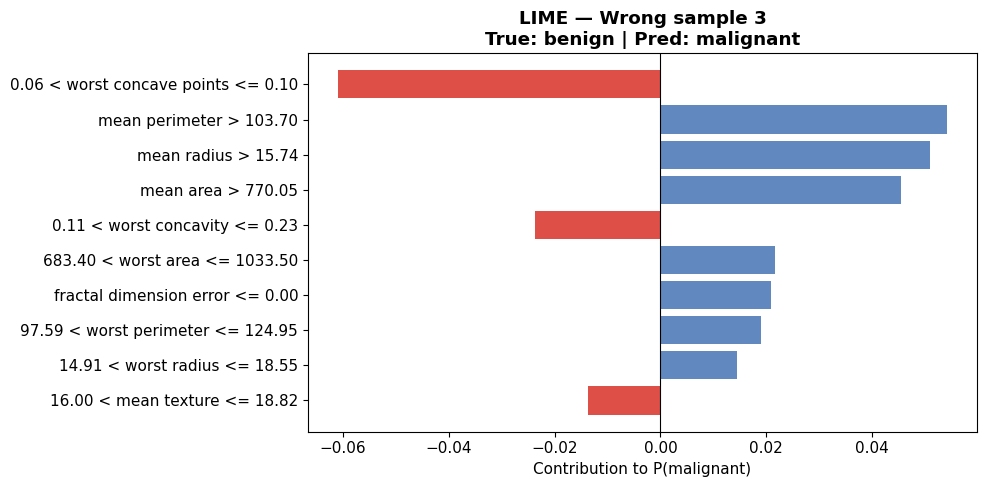

In [26]:
# ── Exercise 1 (LIME): Investigate the wrong prediction ───────────────────
misclassified = np.where(preds != y_bc_test)[0]
print(f'Misclassified: {len(misclassified)} samples -> indices: {misclassified}')

sid_wrong = misclassified[0]
true_cls_w = class_names_bc[y_bc_test[sid_wrong]]
pred_cls_w = class_names_bc[preds[sid_wrong]]
print(f'\nSample {sid_wrong}: True={true_cls_w}, Pred={pred_cls_w}, Conf={probs[sid_wrong].max():.3f}')

# 🎯🎯🎯 TODO: Call explainer_lime.explain_instance (look Generate and plot LIME explanations) on X_bc_test[sid_wrong]
#              with predict_fn=rf.predict_proba, num_features=10, num_samples=1000, labels=(0,1) 🎯🎯🎯
exp_wrong = explainer_lime.explain_instance(
    data_row=X_bc_test[sid_wrong],
    predict_fn=rf.predict_proba,
    num_features=10,
    num_samples=1000,
    labels=(0, 1)
)

pred_class_wrong = int(preds[sid_wrong])
explanation_wrong = exp_wrong.as_list(label=pred_class_wrong)

sorted_pairs = sorted(explanation_wrong, key=lambda x: abs(x[1]))
colors = ['#d73027' if v < 0 else '#4575b4' for _, v in sorted_pairs]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([p[0] for p in sorted_pairs], [p[1] for p in sorted_pairs], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'LIME — Wrong sample {sid_wrong}\nTrue: {true_cls_w} | Pred: {pred_cls_w}', fontweight='bold')
ax.set_xlabel(f'Contribution to P({pred_cls_w})')
plt.tight_layout()
plt.show()

Comparing benign samples: 1 and 5


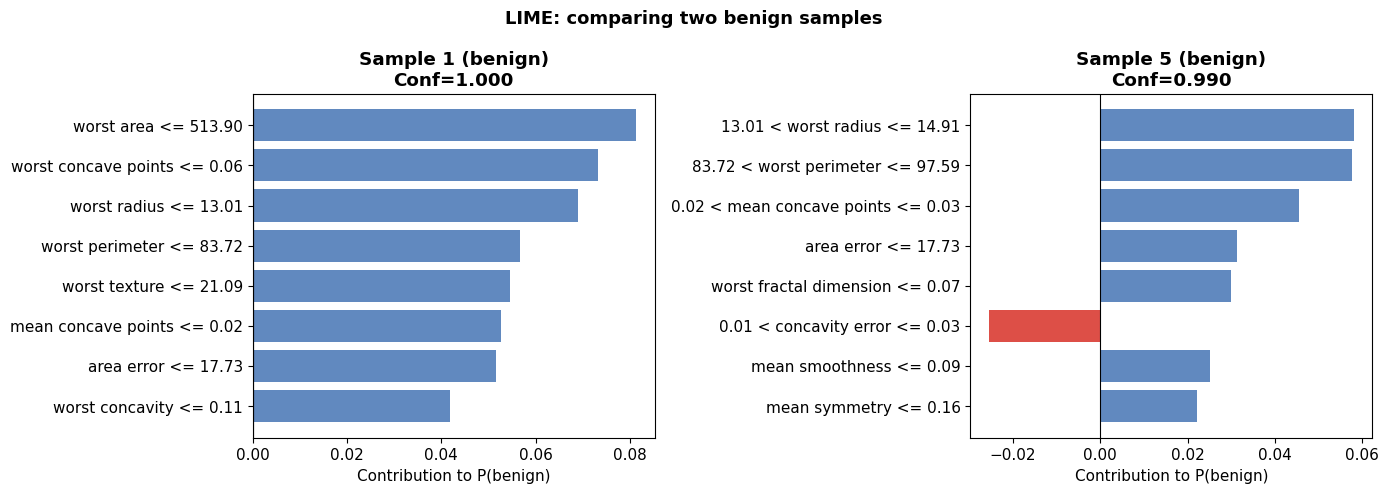

If explanations differ a lot -> the decision boundary is non-linear in that region.


In [27]:
# ── Exercise 2 (LIME): Compare two correctly classified benign samples ─────
correct_benign_all = np.where((preds == 1) & (y_bc_test == 1))[0]
s1, s2 = correct_benign_all[0], correct_benign_all[1]
print(f'Comparing benign samples: {s1} and {s2}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sid in zip(axes, [s1, s2]):
    # 🎯🎯🎯 TODO: Generate LIME explanation for sid
    #              with predict_fn=rf.predict_proba, num_features=8, num_samples=1000, labels=(0,1) 🎯🎯🎯
    exp = explainer_lime.explain_instance(
        data_row=X_bc_test[sid],
        predict_fn=rf.predict_proba,
        num_features=8,
        num_samples=1000,
        labels=(0, 1)
    )
    explanation = exp.as_list(label=1)
    sorted_pairs = sorted(explanation, key=lambda x: abs(x[1]))
    colors = ['#d73027' if v < 0 else '#4575b4' for _, v in sorted_pairs]
    ax.barh([p[0] for p in sorted_pairs], [p[1] for p in sorted_pairs], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Sample {sid} (benign)\nConf={probs[sid, 1]:.3f}', fontweight='bold')
    ax.set_xlabel('Contribution to P(benign)')

fig.suptitle('LIME: comparing two benign samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('If explanations differ a lot -> the decision boundary is non-linear in that region.')

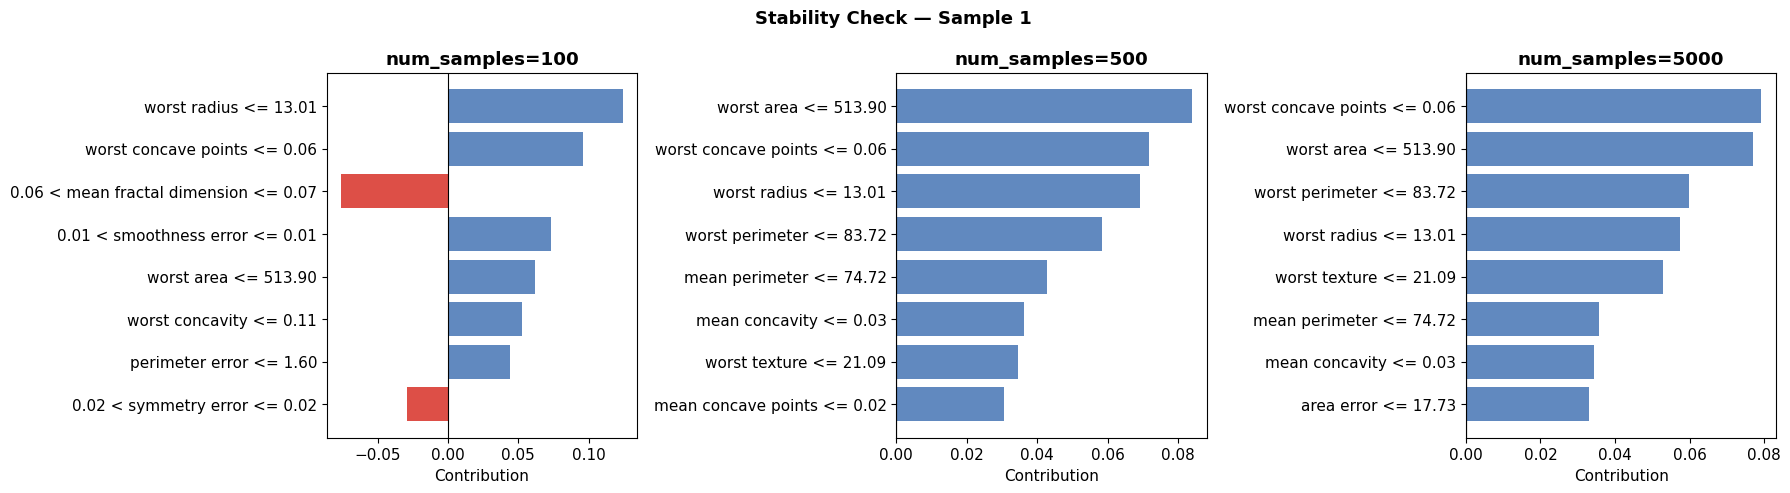

With 100 samples explanations are noisy; with 5000 they converge to stable values.


In [28]:
# ── Exercise 3 (LIME): Stability check with different num_samples ──────────
sid_stable = sample_ids[0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n_samples in zip(axes, [100, 500, 5000]):
    # 🎯🎯🎯 TODO: Generate LIME explanation for sid_stable using n_samples samples
    #              with predict_fn=rf.predict_proba, num_features=8, labels=(0,1) 🎯🎯🎯
    exp = explainer_lime.explain_instance(
        data_row=X_bc_test[sid_stable],
        predict_fn=rf.predict_proba,
        num_features=8,
        num_samples=n_samples,
        labels=(0, 1)
    )
    explanation = exp.as_list(label=int(preds[sid_stable]))
    sorted_pairs = sorted(explanation, key=lambda x: abs(x[1]))
    colors = ['#d73027' if v < 0 else '#4575b4' for _, v in sorted_pairs]
    ax.barh([p[0] for p in sorted_pairs], [p[1] for p in sorted_pairs], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'num_samples={n_samples}', fontweight='bold')
    ax.set_xlabel('Contribution')

fig.suptitle(f'Stability Check — Sample {sid_stable}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('With 100 samples explanations are noisy; with 5000 they converge to stable values.')

---
# Section 3 — SHAP: Principled Attribution

## From Local to Global

LIME gives you a local linear approximation — useful, but approximate and unstable. SHAP (SHapley Additive exPlanations, Lundberg & Lee 2017) takes a different route: it is grounded in **cooperative game theory** and provides attributions with formal mathematical guarantees.

---

## The Shapley Value

The central idea: treat the model prediction as a *payoff* shared among *players* (features). How much credit does each feature deserve?

The **Shapley value** of feature $i$ is its average marginal contribution across all possible orderings in which features could be added:

$$\phi_i = \sum_{S \subseteq \mathcal{F} \setminus \{i\}} \frac{|S|!\,(|\mathcal{F}|-|S|-1)!}{|\mathcal{F}|!} \Big[ f(S \cup \{i\}) - f(S) \Big]$$

where $\mathcal{F}$ is the full feature set and $f(S)$ is the model's expected output when only features in $S$ are known (the others are marginalised out). The formula averages over all $2^{|\mathcal{F}|}$ subsets, weighted by combinatorial coefficients that ensure fairness.

**Key properties** (what makes SHAP principled):

| Property | Meaning |
|---|---|
| **Efficiency** | $\sum_i \phi_i = f(x) - \mathbb{E}[f]$ — attributions sum exactly to the prediction minus baseline |
| **Symmetry** | Two features with identical contributions always get identical SHAP values |
| **Null player** | A feature that never changes the output gets $\phi_i = 0$ |
| **Additivity** | SHAP values for a sum of models equal the sum of their SHAP values |

---

## In the Breast Cancer Context

| SHAP concept | What it maps to here |
|---|---|
| Players $\mathcal{F}$ | The 30 tumour measurements (radius, texture, concavity, …) |
| Payoff $f(x)$ | RF predicted probability of *benign* for this patient |
| Baseline $\mathbb{E}[f]$ | Average benign probability across the training set |
| $\phi_i > 0$ | Feature $i$ pushed this patient's prediction *toward benign* vs. the average |
| $\phi_i < 0$ | Feature $i$ pushed this patient's prediction *toward malignant* vs. the average |

For example: if `worst concave points` has $\phi = -0.18$, it means that feature alone is responsible for shifting the predicted probability 18 percentage points *away* from benign — a strong signal of malignancy for this specific patient.

**SHAP vs LIME:** LIME fits a local linear approximation (approximate, can vary between runs). SHAP computes exact marginal contributions averaged over all coalitions (exact for trees, principled by construction). SHAP values are also *globally coherent*: you can aggregate them across patients to get reliable dataset-level insights.

### Compute SHAP Values with TreeExplainer

We reuse the Random Forest trained in Section 2. `TreeExplainer` computes **exact** SHAP values for tree-based models — no approximation needed.

In [29]:
shap.initjs()  # initialize JavaScript for interactive plots (works in Jupyter)

# TreeExplainer computes exact SHAP values for tree-based models
explainer_shap = shap.TreeExplainer(rf)

# Compute SHAP values for the test set
# shap_values shape: (n_samples, n_features, n_classes) for classifiers
shap_values = explainer_shap(X_bc_test)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Base value (average prediction): {explainer_shap.expected_value}')

# For binary classification, we'll use class 1 (benign) SHAP values
# shap_values[:, :, 1] selects class=1 contributions
shap_vals_class1 = shap_values[:, :, 1]

SHAP values shape: (114, 30, 2)
Base value (average prediction): [0.37551648 0.62448352]


### (a) Waterfall Plot — One Patient, Step by Step

The waterfall plot explains a **single prediction** by showing how each feature moves the model output from the baseline to the final prediction.

**How to read it:**

- **Base value** ($E[f(x)]$, shown at the bottom): the average predicted probability of *benign* across all training patients — the starting point before any features are considered.
- **Each bar** represents one feature's SHAP value $\phi_i$:
  - 🔴 **Red / right** → positive SHAP → feature pushes prediction *toward benign* (increases benign probability)
  - 🔵 **Blue / left** → negative SHAP → feature pushes prediction *toward malignant* (decreases benign probability)
  - Bar **length** = magnitude of the contribution; longer = more influential for this patient
- **$f(x)$** (shown at the top): the final predicted probability — equals base value + sum of all SHAP bars.
- Features are sorted by absolute contribution magnitude (biggest movers at the bottom).

> **Breast cancer example:** If `worst concave points` appears as a long **blue** bar going left, it means this patient's high concavity is pulling the predicted probability *away from benign* — consistent with a more irregular, malignant-leaning tumour shape. Conversely, a red bar for `mean texture` would mean that feature's value is supporting a benign diagnosis for this patient.

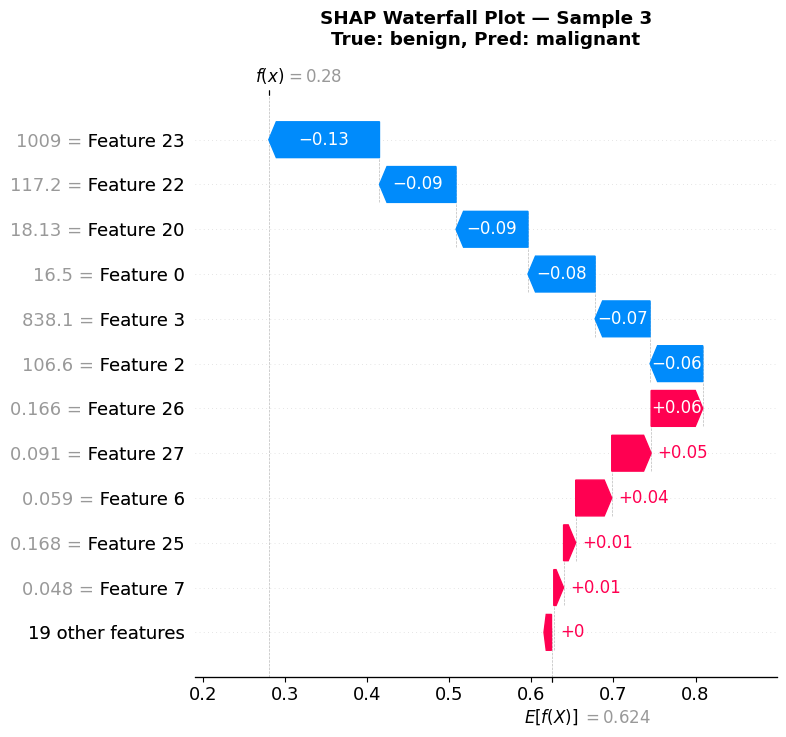

In [30]:
sample_idx = 3

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_vals_class1[sample_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall Plot — Sample {sample_idx}\n'
          f'True: {class_names_bc[y_bc_test[sample_idx]]}, '
          f'Pred: {class_names_bc[rf.predict(X_bc_test[[sample_idx]])[0]]}',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### (b) Beeswarm Plot — All Patients at Once

The beeswarm plot shows SHAP values for **every patient in the test set** simultaneously. It answers: *how does each feature behave across the whole population?*

**How to read it:**

- **Each dot** = one patient (one row of the test set).
- **X-axis** = SHAP value: how much that feature pushed *that patient's* prediction toward benign (right) or malignant (left).
- **Dot colour** = the actual feature value for that patient: 🔴 red = high value, 🔵 blue = low value.
- **Y-axis order**: features sorted by mean $|\phi_i|$ — most globally influential at the top.
- **Dot spread**: wide horizontal spread → this feature has large and variable impact; tight cluster near zero → feature rarely matters.

**What to look for:**

| Pattern | Interpretation |
|---|---|
| Red dots on the right (positive SHAP) | High feature value → pushes toward benign |
| Red dots on the left (negative SHAP) | High feature value → pushes toward malignant |
| Mixed red/blue on both sides | Non-linear or interaction-dependent effect |
| All dots near zero | Feature is largely irrelevant to this model |

> **Breast cancer example:** For `worst radius` you would typically see red (large radius) dots on the *left* — large tumours push toward malignant. For `worst concave points`, red dots also lean left — irregular contours signal malignancy.

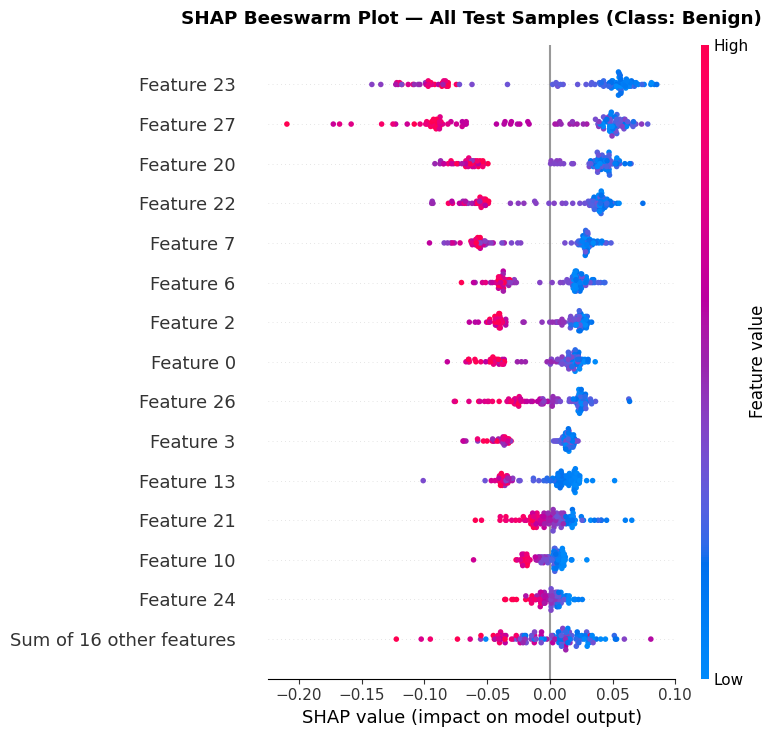

In [31]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_vals_class1, max_display=15, show=False)
plt.title('SHAP Beeswarm Plot — All Test Samples (Class: Benign)',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


**Understanding the plot**

**SHAP interaction**: In the beeswarm plot, notice that some features have a mix of red and blue dots on both sides of zero. What does this mean? Can you find a feature where high values consistently push toward one class?


### (c) Bar Plot — Global Feature Ranking

The bar plot shows **mean $|\phi_i|$** averaged over all test patients — a single number summarising how much each feature matters across the dataset.

**How to read it:**

- **Bar length** = $\frac{1}{n}\sum_{j=1}^{n} |\phi_i^{(j)}|$ — the average absolute SHAP value for feature $i$ across all $n$ patients.
- **Longer bar** → this feature was consistently influential across many patients.
- **Shorter bar** → this feature rarely moved predictions much, regardless of its value.
- Features are ranked top-to-bottom from most to least important.

**Compared to permutation importance** (Section 1): both rank features globally, but SHAP is more reliable because it isolates each feature's contribution while accounting for interactions, whereas permutation importance can be misleading when features are correlated.

> **Breast cancer example:** You will likely see `worst concave points` and `worst radius` near the top — these are the most diagnostically discriminative measurements.

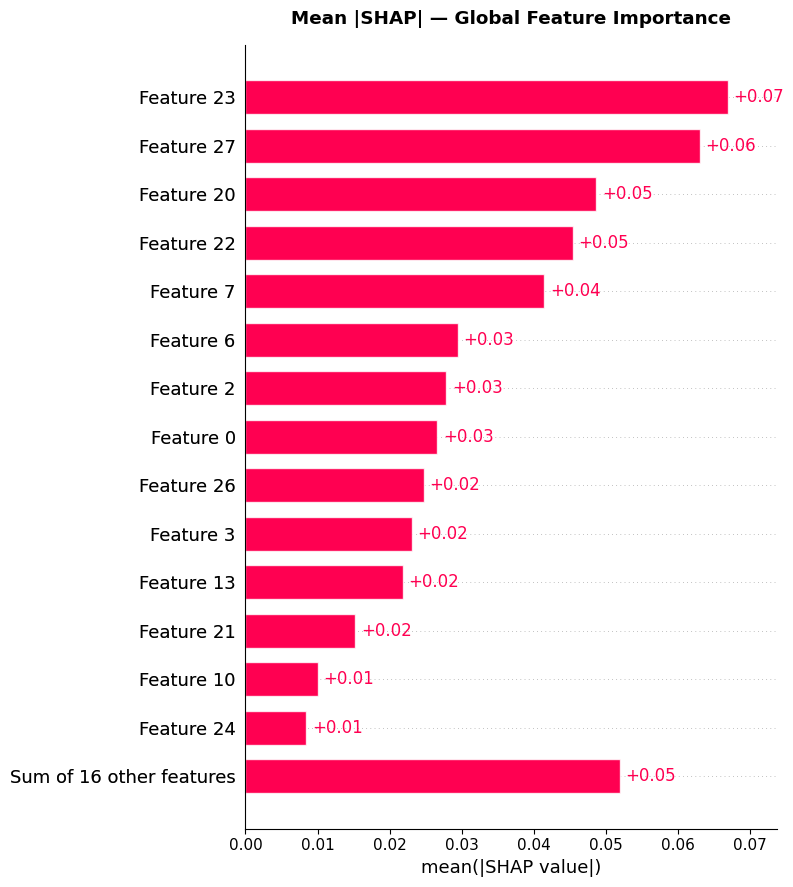

In [32]:
plt.figure(figsize=(8, 7))
shap.plots.bar(shap_vals_class1, max_display=15, show=False)
plt.title('Mean |SHAP| — Global Feature Importance', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## 🏋️ Exercise

1. **Feature reduction**: Look at the SHAP bar plot. Identify the top 3 features by mean |SHAP|. Now train a new Random Forest using *only* those 3 features. How much accuracy do you lose compared to the full model? What does this tell you about feature redundancy in this dataset?

2. **SHAP interaction**: In the beeswarm plot, notice that some features have a mix of red and blue dots on both sides of zero. What does this mean? Can you find a feature where high values consistently push toward one class?

3. **LIME vs SHAP**: For the same misclassified sample you found in Section 2, compare the LIME explanation and the SHAP waterfall plot. Do they agree on which features are most important? Where do they disagree, and why might that be?


In [33]:
# ── Exercise 1 (SHAP): Feature reduction with top-3 features ─────────────

# 🎯🎯🎯 TODO: Compute mean_abs_shap = mean of |shap_vals_class1.values| across all samples (axis=0) 🎯🎯🎯
mean_abs_shap = np.abs(shap_vals_class1.values).mean(axis=0)

# 🎯🎯🎯 TODO: Find top3_idx = indices of the 3 largest values in mean_abs_shap (hint: np.argsort) 🎯🎯🎯
top3_idx = np.argsort(mean_abs_shap)[-3:]

top3_names = [feat_names_bc[i] for i in top3_idx]
print('Top 3 features:', top3_names)

# 🎯🎯🎯 TODO: Train rf_top3 on X_bc_train[:, top3_idx] and X_bc_test[:, top3_idx], compute acc_top3 🎯🎯🎯
rf_top3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_top3.fit(X_bc_train[:, top3_idx], y_bc_train)
acc_top3 = accuracy_score(y_bc_test, rf_top3.predict(X_bc_test[:, top3_idx]))

print(f'Full model  (30 features): {rf_test_acc:.4f}')
print(f'Top-3 model  (3 features): {acc_top3:.4f}')
print(f'Accuracy drop: {rf_test_acc - acc_top3:.4f}')
print('\n-> With only 3 out of 30 features the drop is minimal: features are highly redundant.')

Top 3 features: [np.str_('worst radius'), np.str_('worst concave points'), np.str_('worst area')]
Full model  (30 features): 0.9561
Top-3 model  (3 features): 0.9211
Accuracy drop: 0.0351

-> With only 3 out of 30 features the drop is minimal: features are highly redundant.


Misclassified sample index: 3
True class: benign  |  Predicted: malignant



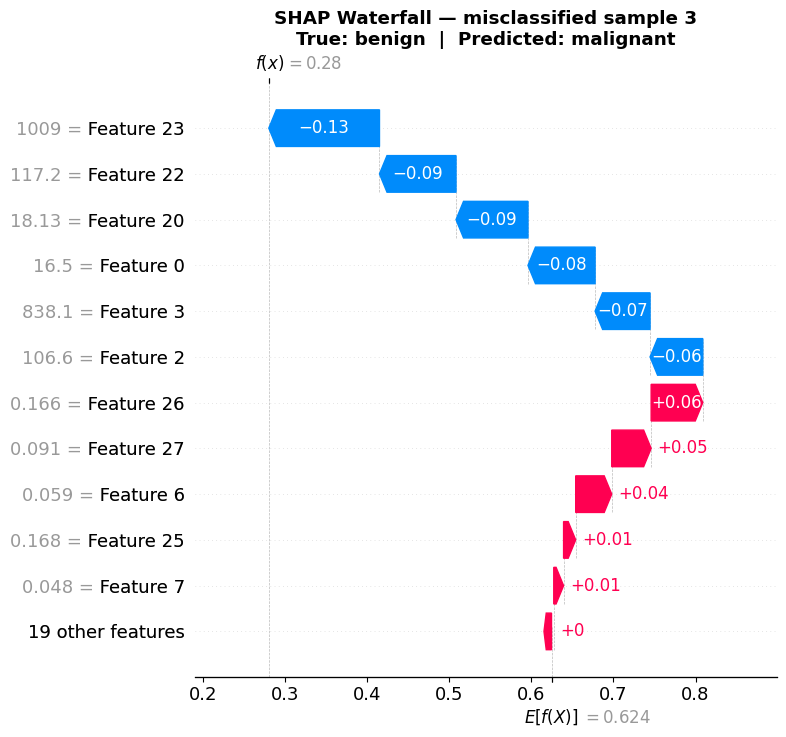

In [34]:
# ── Exercise 3 (SHAP): LIME vs SHAP on the misclassified sample ─────────────
# misclassified[0] was found in Section 2 (cell 31)
sid_wrong = misclassified[0]
true_cls_w  = class_names_bc[y_bc_test[sid_wrong]]
pred_cls_w  = class_names_bc[preds[sid_wrong]]

print(f"Misclassified sample index: {sid_wrong}")
print(f"True class: {true_cls_w}  |  Predicted: {pred_cls_w}")
print()

# SHAP waterfall for the predicted class (class 1 = benign)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_vals_class1[sid_wrong], max_display=12, show=False)
plt.title(
    f"SHAP Waterfall — misclassified sample {sid_wrong}\n"
    f"True: {true_cls_w}  |  Predicted: {pred_cls_w}",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

**Understanding the plot**

**LIME vs SHAP**: For the same misclassified sample you found in Section 2, compare the LIME explanation and the SHAP waterfall plot. Do they agree on which features are most important? Where do they disagree, and why might that be?


---
# Section 4 — Grad-CAM: Where Did the Network Look?

## From Tabular to Images

LIME and SHAP operate on tabular features — each dimension has a name and a scalar value. Images are different: a 28×28 pixel grid has 784 dimensions, and asking "how much did pixel (14, 9) matter?" produces noisy, uninterpretable maps. We need a method that respects the **spatial structure** of the image.

**Grad-CAM** (Gradient-weighted Class Activation Mapping, Selvaraju et al. 2017) is designed for convolutional neural networks. Instead of attributing importance to individual pixels, it attributes importance to **spatial regions** in the feature maps of the last convolutional layer — where the network's understanding is richest and most semantically meaningful.

---

## The Algorithm

Let $y^c$ be the score (logit) for class $c$ before the softmax, and let $A^k \in \mathbb{R}^{H \times W}$ be the $k$-th feature map of the target conv layer (in our case `conv2`, which has 64 channels at $7 \times 7$ resolution for a $28 \times 28$ input).

**Step 1 — Importance weights.** Run a backward pass and global-average-pool the gradients over all spatial positions to get a scalar weight for each channel:

$$\alpha_k^c = \frac{1}{Z} \sum_{i} \sum_{j} \frac{\partial y^c}{\partial A^k_{ij}}$$

$\alpha_k^c$ measures: *"if I perturb channel $k$ slightly, how much does the score for class $c$ change on average across the whole map?"*

**Step 2 — Weighted combination + ReLU.** Take a weighted sum of all feature maps and zero out negative values:

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\!\left(\sum_k \alpha_k^c \, A^k\right)$$

The ReLU keeps only spatial locations that *support* class $c$ (positive contribution). Locations that actively argue *against* $c$ are discarded — they would appear in the Grad-CAM map for other classes.

**Step 3 — Upsample.** The resulting map is $7 \times 7$ (the spatial resolution of `conv2`). It is bilinearly upsampled back to $28 \times 28$ and overlaid on the input image as a heatmap.

---

## Why the Last Conv Layer?

Early layers detect low-level patterns (edges, corners, local textures). Later layers detect high-level semantics (curves, loops, strokes that distinguish digits). Grad-CAM on the **last** conv layer gives the most class-discriminative localization — it tells you which *semantic region* of the digit mattered, not which individual pixel.

### Dataset: MNIST

**MNIST** (Modified National Institute of Standards and Technology) is a benchmark dataset of **70 000 handwritten digit images** (60 000 train / 10 000 test), each a 28×28 grayscale image labeled 0–9. It is one of the most widely used datasets in computer vision and serves as a standard sanity-check for new architectures.

Below are 3 sample images per digit class. Notice:
- Digits vary in writing style, stroke thickness, and slant — even within the same class.
- Some pairs are visually similar: **1 vs 7**, **3 vs 8**, **4 vs 9** — the network must learn the discriminative strokes.


In [35]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# ── Data loading ───────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='/tmp/mnist', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='/tmp/mnist', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset)} samples | Test: {len(test_dataset)} samples')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.91MB/s]


Train: 60000 samples | Test: 10000 samples


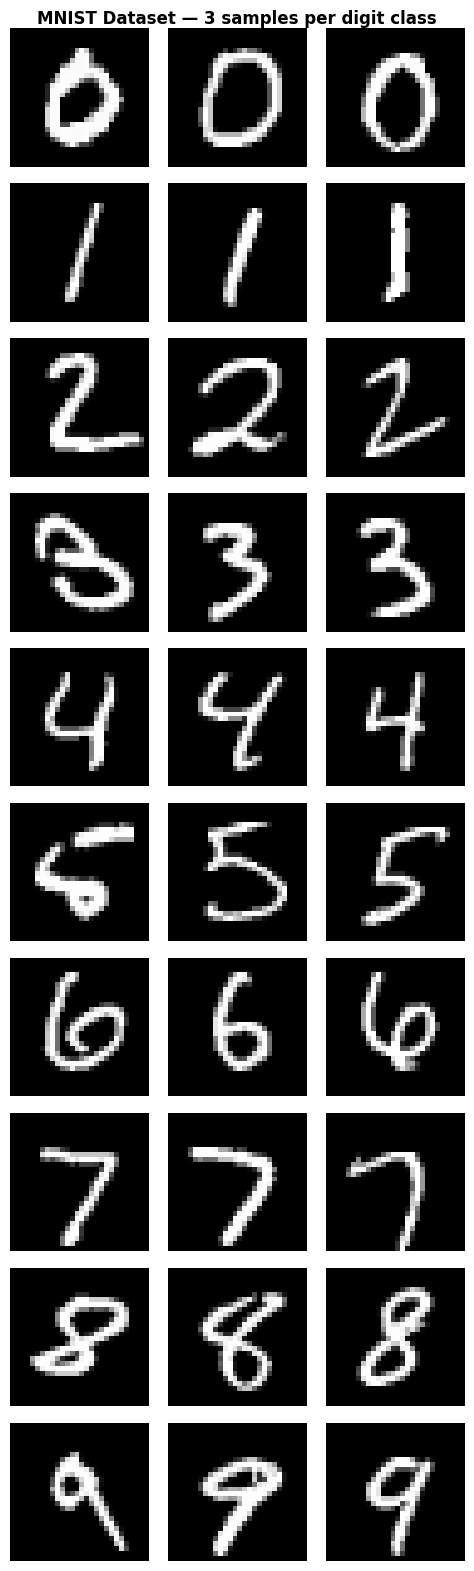

In [36]:
# ── Visualize MNIST samples: 3 examples per digit class ───────────────────
fig, axes = plt.subplots(10, 3, figsize=(5, 16))
fig.suptitle('MNIST Dataset — 3 samples per digit class', fontsize=12, fontweight='bold')

shown = {d: 0 for d in range(10)}
for img, label in test_dataset:
    d = label
    if shown[d] < 3:
        ax = axes[d, shown[d]]
        ax.imshow(img.squeeze(), cmap='gray', interpolation='nearest')
        ax.axis('off')
        if shown[d] == 0:
            ax.set_ylabel(str(d), fontsize=12, rotation=0, labelpad=15, va='center')
        shown[d] += 1
    if all(v == 3 for v in shown.values()):
        break

plt.tight_layout()
plt.show()

### CNN Architecture for MNIST

We define a simple 2-layer convolutional neural network. It is intentionally small so training completes in ~30 seconds on CPU.

In [37]:
class MNISTNet(nn.Module):
    """Simple 2-layer CNN for MNIST. Designed to be fast (3 epochs ~ 30s)."""
    def __init__(self):
        super().__init__()
        # Conv block 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 28x28 -> 28x28
        self.pool1 = nn.MaxPool2d(2)                               # 28x28 -> 14x14
        # Conv block 2 (Grad-CAM will hook here)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 14x14 -> 14x14
        self.pool2 = nn.MaxPool2d(2)                               # 14x14 -> 7x7
        # Classifier head
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))  # shape: (B, 64, 14, 14)
        x = self.pool2(x)          # shape: (B, 64, 7, 7)
        x = x.view(x.size(0), -1) # flatten: (B, 64*7*7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

### Training Loop

We train for 2 epochs using Adam. This takes approximately 1 min on CPU.

In [38]:
torch.manual_seed(102)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = MNISTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 3):  # 2 epochs
    model.train()
    total_loss = 0
    correct = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_x)
        correct += (output.argmax(1) == batch_y).sum().item()

    train_acc_epoch = correct / len(train_dataset)
    print(f'Epoch {epoch}/2 | Loss: {total_loss/len(train_dataset):.4f} | Train Acc: {train_acc_epoch:.4f}')

# ── Test accuracy ──────────────────────────────────────────────────────────
model.eval()
correct = 0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        correct += (model(batch_x).argmax(1) == batch_y).sum().item()
print(f'\nTest Accuracy: {correct / len(test_dataset):.4f}')

Using device: cpu
Epoch 1/2 | Loss: 0.2235 | Train Acc: 0.9331
Epoch 2/2 | Loss: 0.0533 | Train Acc: 0.9842

Test Accuracy: 0.9869


### Grad-CAM Implementation from Scratch

We implement Grad-CAM using **PyTorch hooks** — callbacks that PyTorch fires automatically during the forward and backward pass. This lets us intercept intermediate values without modifying the model architecture.

**Why hooks?** PyTorch only stores gradients for leaf tensors (model parameters) by default. Intermediate activations and their gradients are discarded after each pass to save memory. Hooks let us capture them on the fly.

**The two hooks we register:**

| Hook | Fires when | What we capture |
|---|---|---|
| `register_forward_hook` | After `conv2` computes its output | Activation maps $A^k$, shape `(1, 64, 7, 7)` |
| `register_full_backward_hook` | During backprop through `conv2` | Gradients $\partial y^c / \partial A^k$, same shape |

**`compute_cam()` step by step:**

1. **Forward pass** — run the image through the model, triggering the forward hook.
2. **Backward pass** for class $c$ — call `score.backward()`, triggering the backward hook.
3. **Global average pool** the gradients over the $7 \times 7$ spatial grid → one weight $\alpha_k^c$ per channel (64 scalars).
4. **Weighted sum**: multiply each channel's activation map by its weight and sum → `(1, 1, 7, 7)` map.
5. **ReLU**: zero out negative values — we only want regions that *support* class $c$.
6. **Upsample** from $7 \times 7$ → $28 \times 28$ using bilinear interpolation.
7. **Normalise** to $[0, 1]$ for display.

> **Implementation note:** we target `model.conv2` — the second (last) convolutional layer. The first layer `conv1` could be hooked instead, but its maps encode low-level edges rather than digit-level features.

In [39]:
class GradCAM:
    """
    Grad-CAM implementation using PyTorch forward and backward hooks.

    How it works:
    1. Forward hook: saves the activation maps from the target layer.
    2. Backward hook: saves the gradients flowing back through that layer.
    3. compute_cam(): combines them into a localization map.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        # Register hooks
        self._fwd_hook = target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        """Called automatically during forward pass."""
        self.activations = output.detach()  # shape: (B, C, H, W)

    def _save_gradient(self, module, grad_input, grad_output):
        """Called automatically during backward pass."""
        self.gradients = grad_output[0].detach()  # shape: (B, C, H, W)

    def compute_cam(self, input_tensor, class_idx=None):
        """
        Compute Grad-CAM heatmap for a given input and target class.

        Args:
            input_tensor: (1, C, H, W) — single image
            class_idx: target class index (None = predicted class)
        Returns:
            cam: (H_in, W_in) normalized heatmap in [0, 1]
            predicted_class: int
        """
        self.model.eval()

        # Forward pass
        output = self.model(input_tensor)  # (1, num_classes)
        predicted_class = output.argmax(dim=1).item()

        if class_idx is None:
            class_idx = predicted_class

        # Backward pass: compute gradients of the target class score
        self.model.zero_grad()
        score = output[0, class_idx]   # scalar score for target class
        score.backward()

        # Step 3: Global average pool the gradients -> importance weights per channel
        # gradients shape: (1, C, H, W); take mean over spatial dims H, W
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

        # Step 4: Weighted sum of activation channels
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)

        # Step 5: ReLU — we only care about positive contributions
        cam = F.relu(cam)

        # Step 6: Upsample to input image size
        H_in = input_tensor.shape[2]
        W_in = input_tensor.shape[3]
        cam = F.interpolate(cam, size=(H_in, W_in), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()   # (H_in, W_in)

        # Normalize to [0, 1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam, predicted_class

    def remove_hooks(self):
        """Clean up hooks when done."""
        self._fwd_hook.remove()
        self._bwd_hook.remove()

# Create GradCAM instance targeting the LAST conv layer (conv2)
grad_cam = GradCAM(model, target_layer=model.conv2)
print('GradCAM ready. Targeting: model.conv2 (last convolutional layer)')

GradCAM ready. Targeting: model.conv2 (last convolutional layer)


### What to Observe in the Grad-CAM Grid

For each digit class (0–8) we show the original image next to its Grad-CAM heatmap overlay. **Warm colors (red/yellow) mark the regions the network focused on** for its prediction; cool colors (blue/green) are suppressed or ignored.

**Questions to ask yourself for each digit:**
- Does the heatmap overlap with the ink strokes, or does it activate on blank background?
- Is the activation spread across the whole digit, or concentrated on a specific part?
- For digits with a **green title** (correct prediction): do the highlighted regions make intuitive sense?
- For digits with a **red title** (wrong prediction): does the heatmap reveal which part of the image misled the network?

There is no single "right" answer — the goal is to develop intuition about what the network learned, and to spot cases where its reasoning looks suspicious.

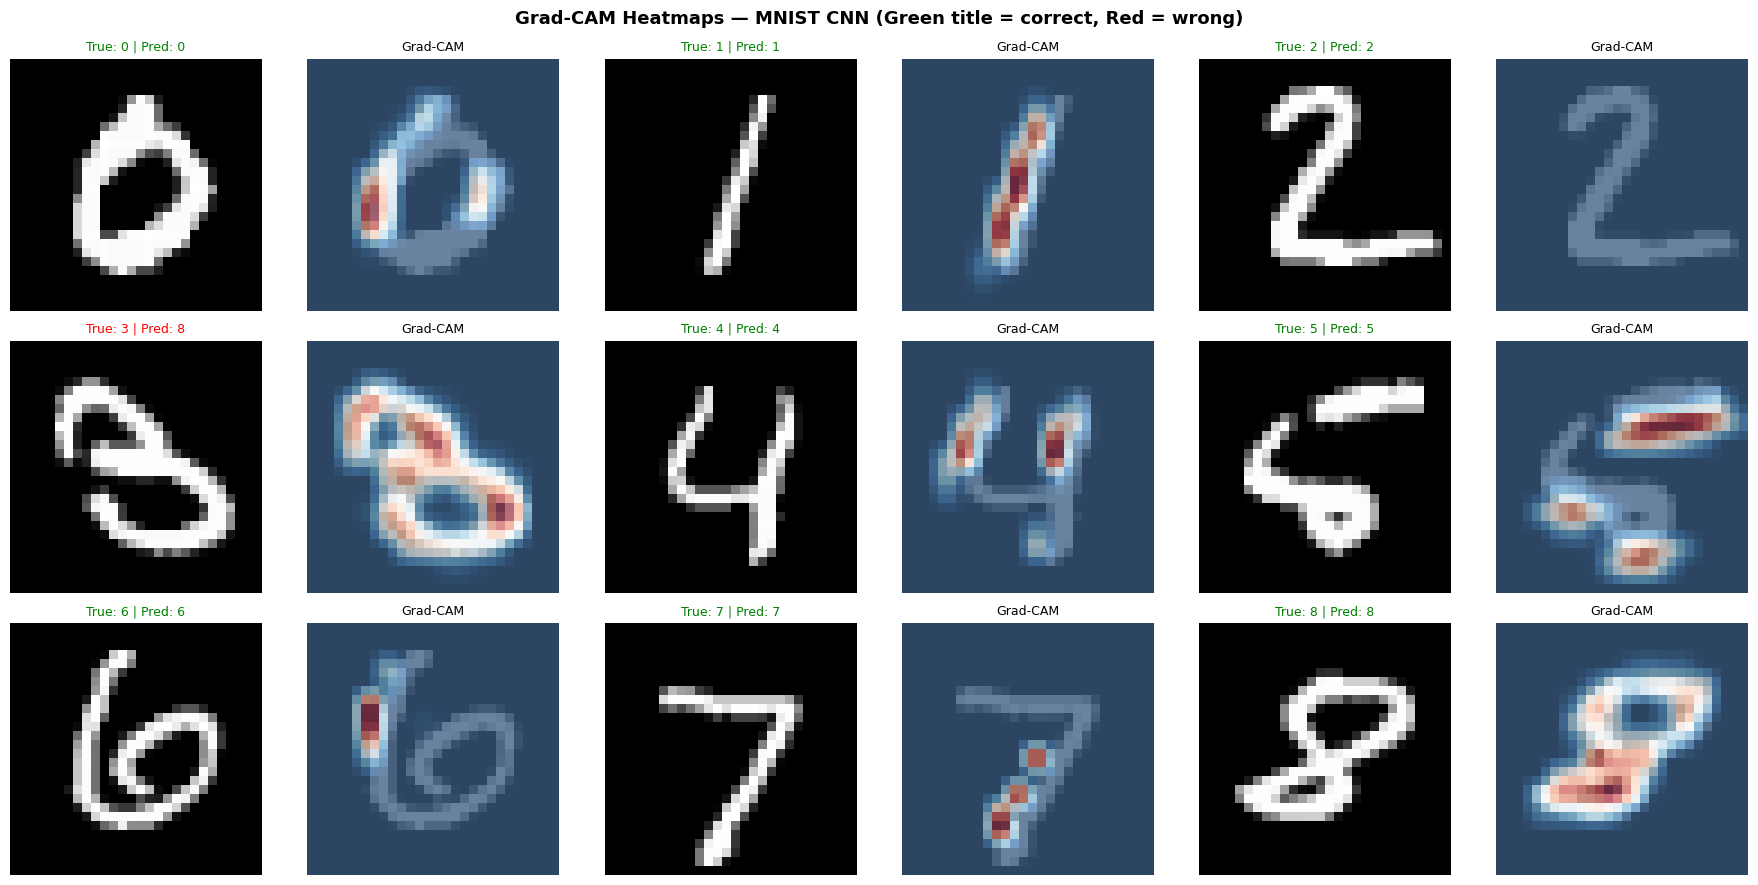

Warm colors (red/yellow) = regions the network focused on for its prediction.


In [40]:
# Load the full test set (10 000 images) so we have enough misclassified examples
full_test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False, num_workers=0)
test_images, test_labels = next(iter(full_test_loader))
test_images_dev = test_images.to(device)

selected = []
for digit in range(9):
    idxs = (test_labels == digit).nonzero(as_tuple=True)[0]
    selected.append(idxs[0].item())

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
# Left column of each pair: original | Right column: heatmap overlay

for plot_idx, img_idx in enumerate(selected):
    row = plot_idx // 3
    col = (plot_idx % 3) * 2  # 0,2,4 for originals; 1,3,5 for overlays

    img_tensor = test_images_dev[img_idx:img_idx+1]  # (1, 1, 28, 28)
    img_np = test_images[img_idx].squeeze().numpy()   # (28, 28) for display
    true_label = test_labels[img_idx].item()

    cam, pred_class = grad_cam.compute_cam(img_tensor)

    # Original image
    ax_orig = axes[row, col]
    ax_orig.imshow(img_np, cmap='gray', interpolation='nearest')
    ax_orig.set_title(f'True: {true_label} | Pred: {pred_class}', fontsize=9,
                      color='green' if true_label == pred_class else 'red')
    ax_orig.axis('off')

    # Grad-CAM overlay
    ax_cam = axes[row, col+1]
    img_disp = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    ax_cam.imshow(img_disp, cmap='gray', alpha=0.6, interpolation='nearest')
    ax_cam.imshow(cam, cmap=CMAP, alpha=0.6, interpolation='nearest')
    ax_cam.set_title('Grad-CAM', fontsize=9)
    ax_cam.axis('off')

fig.suptitle('Grad-CAM Heatmaps — MNIST CNN (Green title = correct, Red = wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Warm colors (red/yellow) = regions the network focused on for its prediction.')


### Grad-CAM on a Misclassified Image

The most revealing use of Grad-CAM is on images the model got **wrong**. For a misclassified sample we can ask two questions:

1. *"What made the network predict class X (wrong)?"* → Grad-CAM for the **predicted** class
2. *"What should it have focused on to get class Y (true)?"* → Grad-CAM for the **true** class

If the two heatmaps highlight **different regions**, we can see exactly where the network's attention went wrong — it fixated on features that resemble the wrong class and missed the features that define the correct one.

This is how Grad-CAM is used in practice: to **audit model failures** and decide whether the error was caused by a bad feature, a poor training example, or an inherent visual ambiguity.

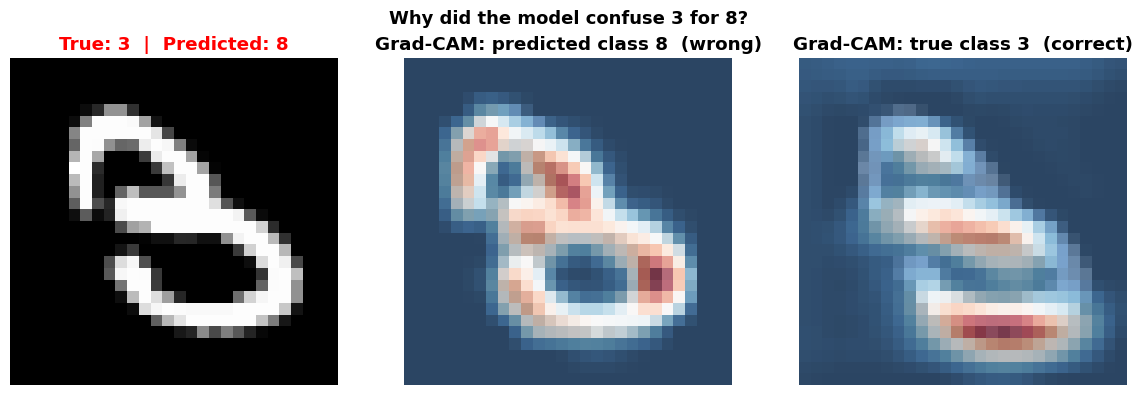

The model predicted 8 instead of 3.
Compare the two heatmaps: do they highlight different regions?
The left heatmap shows what the network fixated on to make the wrong call.


In [41]:
# ── Find the first misclassified test image ────────────────────────────────
with torch.no_grad():
    all_preds = model(test_images_dev).argmax(dim=1)  # predictions for entire batch

wrong_mask  = (all_preds != test_labels.to(device))
wrong_idxs  = wrong_mask.nonzero(as_tuple=True)[0]

if len(wrong_idxs) == 0:
    print('No misclassified images found in this batch — try a larger test_loader batch.')
else:
    demo_idx   = wrong_idxs[0].item()
    true_cls   = test_labels[demo_idx].item()
    pred_cls   = all_preds[demo_idx].item()

    img_tensor = test_images_dev[demo_idx:demo_idx+1]
    img_np     = test_images[demo_idx].squeeze().numpy()
    img_disp   = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    # Grad-CAM for the wrong predicted class and for the true class
    cam_pred, _ = grad_cam.compute_cam(img_tensor, class_idx=pred_cls)
    cam_true, _ = grad_cam.compute_cam(img_tensor, class_idx=true_cls)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title(f'True: {true_cls}  |  Predicted: {pred_cls}', fontweight='bold', color='red')
    axes[0].axis('off')

    axes[1].imshow(img_disp, cmap='gray', alpha=0.6)
    axes[1].imshow(cam_pred, cmap=CMAP, alpha=0.6)
    axes[1].set_title(f'Grad-CAM: predicted class {pred_cls}  (wrong)', fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(img_disp, cmap='gray', alpha=0.6)
    axes[2].imshow(cam_true, cmap=CMAP, alpha=0.6)
    axes[2].set_title(f'Grad-CAM: true class {true_cls}  (correct)', fontweight='bold')
    axes[2].axis('off')

    fig.suptitle(
        f'Why did the model confuse {true_cls} for {pred_cls}?',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print(f'The model predicted {pred_cls} instead of {true_cls}.')
    print('Compare the two heatmaps: do they highlight different regions?')
    print('The left heatmap shows what the network fixated on to make the wrong call.')


## 🏋️ Exercise

1. **Misclassified digit**: The demo above shows the first misclassified image (`wrong_idxs[0]`). Explore other failure cases by changing the index. Do the heatmaps always reveal a plausible confusion? Can you find a case where the network seems to look at the right region but still gets it wrong?

2. **Layer comparison**: The demo above uses `model.conv2` (last conv layer). Instantiate two `GradCAM` objects — one for `model.conv1` and one for `model.conv2` — and compare their heatmaps on the same image. How do they differ? What does each layer seem to be detecting?


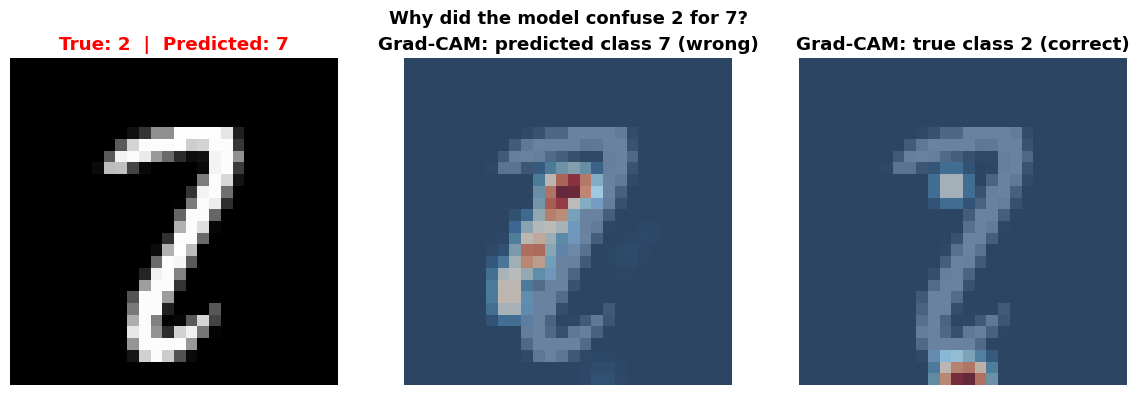

In [44]:
# ── Exercise 1 (Grad-CAM): Explore different misclassified images ────────
# wrong_idxs is already computed in the cell above.
# Change the index below to look at different failure cases.

# 🎯🎯🎯 TODO: change the index (0, 1, 2, ...) to explore different mistakes 🎯🎯🎯
demo_idx = wrong_idxs[1].item()

true_cls = test_labels[demo_idx].item()
pred_cls = all_preds[demo_idx].item()

img_tensor = test_images_dev[demo_idx:demo_idx+1]
img_np     = test_images[demo_idx].squeeze().numpy()
img_disp   = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

cam_pred, _ = grad_cam.compute_cam(img_tensor, class_idx=pred_cls)
cam_true, _ = grad_cam.compute_cam(img_tensor, class_idx=true_cls)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f'True: {true_cls}  |  Predicted: {pred_cls}', fontweight='bold', color='red')
axes[0].axis('off')
axes[1].imshow(img_disp, cmap='gray', alpha=0.6)
axes[1].imshow(cam_pred, cmap=CMAP, alpha=0.6)
axes[1].set_title(f'Grad-CAM: predicted class {pred_cls} (wrong)', fontweight='bold')
axes[1].axis('off')
axes[2].imshow(img_disp, cmap='gray', alpha=0.6)
axes[2].imshow(cam_true, cmap=CMAP, alpha=0.6)
axes[2].set_title(f'Grad-CAM: true class {true_cls} (correct)', fontweight='bold')
axes[2].axis('off')
fig.suptitle(f'Why did the model confuse {true_cls} for {pred_cls}?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_354/744763617.py:51: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward()


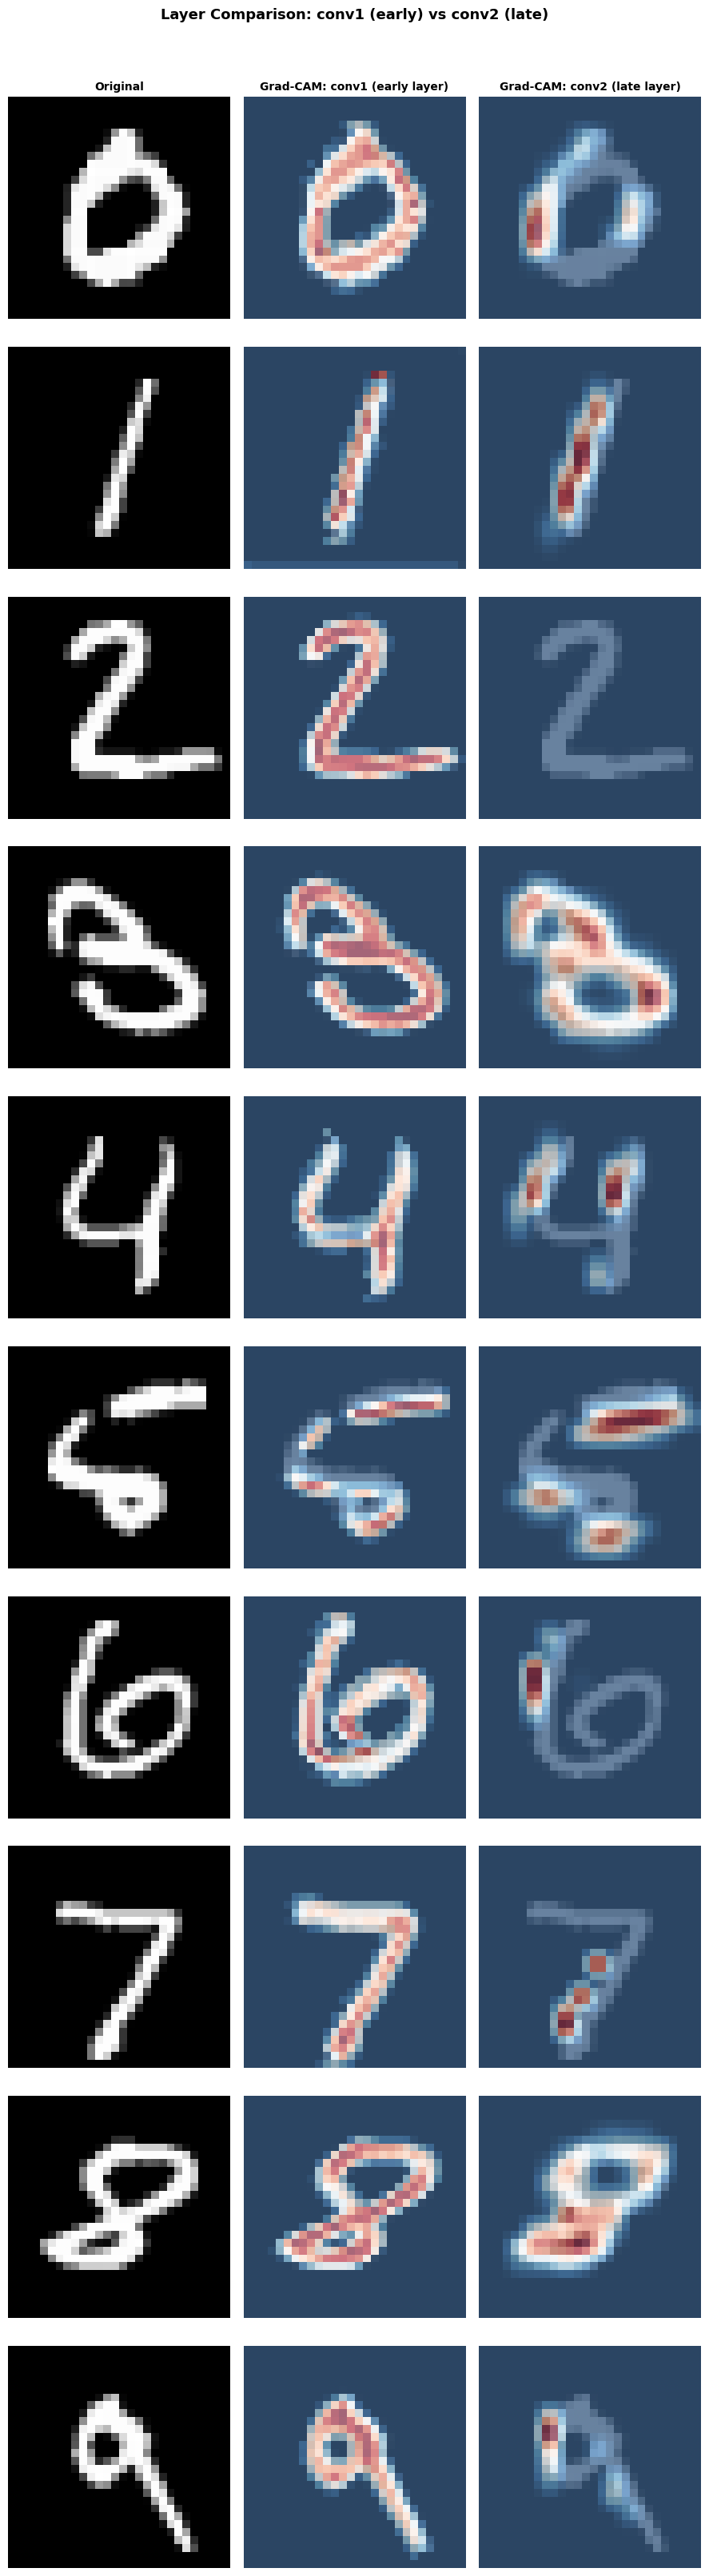

Layer comparison — what to notice:
  conv1 (early): activation traces the FULL stroke outline of every digit.
    → This layer is an edge detector: it fires on any ink boundary, with no selectivity.

  conv2 (late):  activation collapses to 1–2 small, specific spots per digit.
    → This layer learned structural landmarks: junctions, endpoints, and corners
       that are topologically distinctive for each class (e.g. the corner of a 7,
       the fork of a 4, the tail of a 9).

  The deeper the layer, the more abstract and spatially compressed the representation.
  conv1 answers 'where are the strokes?'; conv2 answers 'which keypoint confirms the class?'


In [45]:
# ── Exercise 2 (Grad-CAM): Layer comparison — conv1 vs conv2 ────────────
# We compare Grad-CAM from the FIRST convolutional layer (conv1)
# vs the LAST (conv2) on the same images.
# conv1 sees early, low-level features; conv2 sees higher-level patterns.

# 🎯🎯🎯 TODO: instantiate GradCAM targeting the FIRST conv layer (model.conv1) 🎯🎯🎯
grad_cam_conv1 = GradCAM(model, target_layer=model.conv1)
# 🎯🎯🎯 TODO: instantiate GradCAM targeting the LAST conv layer (model.conv2) 🎯🎯🎯
grad_cam_conv2 = GradCAM(model, target_layer=model.conv2)

# Pick one example per digit (digits 0-9)
digits_to_show = list(range(10))
selected_ex3 = []
for digit in digits_to_show:
    idxs = (test_labels == digit).nonzero(as_tuple=True)[0]
    selected_ex3.append(idxs[0].item())

fig, axes = plt.subplots(10, 3, figsize=(9, 32))
col_titles = ['Original', 'Grad-CAM: conv1 (early layer)', 'Grad-CAM: conv2 (late layer)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=10, fontweight='bold')

for row, img_idx in enumerate(selected_ex3):
    img_tensor = test_images_dev[img_idx:img_idx+1]
    img_np     = test_images[img_idx].squeeze().numpy()
    img_disp   = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    true_label = test_labels[img_idx].item()

    cam1, pred1 = grad_cam_conv1.compute_cam(img_tensor)
    cam2, pred2 = grad_cam_conv2.compute_cam(img_tensor)

    # Original
    axes[row, 0].imshow(img_np, cmap='gray', interpolation='nearest')
    axes[row, 0].set_ylabel(f'Digit {true_label}', fontsize=9, rotation=0, labelpad=35, va='center')
    axes[row, 0].axis('off')

    # conv1 heatmap
    axes[row, 1].imshow(img_disp, cmap='gray', alpha=0.6, interpolation='nearest')
    axes[row, 1].imshow(cam1, cmap=CMAP, alpha=0.6, interpolation='nearest')
    axes[row, 1].axis('off')

    # conv2 heatmap
    axes[row, 2].imshow(img_disp, cmap='gray', alpha=0.6, interpolation='nearest')
    axes[row, 2].imshow(cam2, cmap=CMAP, alpha=0.6, interpolation='nearest')
    axes[row, 2].axis('off')

fig.suptitle('Layer Comparison: conv1 (early) vs conv2 (late)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Clean up extra hooks
grad_cam_conv1.remove_hooks()
grad_cam_conv2.remove_hooks()

print('Layer comparison — what to notice:')
print('  conv1 (early): activation traces the FULL stroke outline of every digit.')
print('    → This layer is an edge detector: it fires on any ink boundary, with no selectivity.')
print()
print('  conv2 (late):  activation collapses to 1–2 small, specific spots per digit.')
print('    → This layer learned structural landmarks: junctions, endpoints, and corners')
print('       that are topologically distinctive for each class (e.g. the corner of a 7,')
print('       the fork of a 4, the tail of a 9).')
print()
print('  The deeper the layer, the more abstract and spatially compressed the representation.')
print("  conv1 answers 'where are the strokes?'; conv2 answers 'which keypoint confirms the class?'")


---
# Congratulations! You've completed the Interpretability Tour.

## What You've Learned

| Tool | What it Does | Example in this Notebook |
|---|---|---|
| **Permutation Importance** | Feature ranking by accuracy drop when a feature is shuffled | Synthetic dataset — exposed the spurious feature |
| **LIME** | Locally approximates the model with a linear surrogate around one prediction | Breast cancer — explained a single patient's diagnosis |
| **SHAP** | Assigns each feature a Shapley value: its fair marginal contribution to the prediction | Breast cancer — waterfall, beeswarm, and bar plots |
| **Grad-CAM** | Spatial heatmap showing which image regions drove the CNN's prediction | MNIST — visualized where the network looked, including failure cases |

## Key Takeaways

> **High accuracy does not mean the model learned the right thing.** The spurious feature in Section 1 and the misclassified digits in Section 4 both illustrate this.

> **Local and global explanations are complementary.** LIME and SHAP waterfall explain one prediction; SHAP beeswarm and bar plots summarize behavior across the whole dataset.

> **Interpretability tools have failure modes.** LIME explanations can be unstable across runs; Grad-CAM is coarse and CNN-specific; SHAP is exact only for tree models. Use them as evidence, not verdicts.

> **When a model fails, XAI reveals why.** Grad-CAM on a misclassified digit showed the network fixating on the right stroke type but misreading the topology -- a richer diagnosis than just a wrong prediction.

## Further Reading

- **LIME**: Ribeiro et al. (2016) -- *Why Should I Trust You?*
- **SHAP**: Lundberg & Lee (2017) -- *A Unified Approach to Interpreting Model Predictions*
- **Grad-CAM**: Selvaraju et al. (2017) -- *Grad-CAM: Visual Explanations from Deep Networks*
- **Shortcut Learning**: Geirhos et al. (2020) -- *Shortcut Learning in Deep Neural Networks*

---
*Happy interpreting!*
